In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('D:/Data Analysis/Space Mission Analysis/Dataset/Space_Missions_Dataset.csv')

In [3]:
df['Launch_Year'] = df['Launch_Date'].str.split("-").str[0]

In [4]:
df.columns

Index(['Mission_ID', 'Mission_Name', 'Agency', 'Country_Region', 'Agency_Type',
       'Program_Type', 'Mission_Category', 'Sub_Category', 'Launch_Date',
       'End_Date', 'Duration', 'Launch_Vehicle', 'Launch_Site', 'Status',
       'Mission_Phase', 'Crew_Type', 'Crew_Members', 'Destination',
       'Objective', 'Key_Achievement', 'Cost_USD_Million', 'Partner_Agencies',
       'Data_Returned', 'Failure_Reason', 'Mission_Outcome_Detail',
       'Reference_URL', 'Launch_Year'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Mission_ID              10500 non-null  object 
 1   Mission_Name            10500 non-null  object 
 2   Agency                  10500 non-null  object 
 3   Country_Region          10500 non-null  object 
 4   Agency_Type             10500 non-null  object 
 5   Program_Type            10500 non-null  object 
 6   Mission_Category        10500 non-null  object 
 7   Sub_Category            10500 non-null  object 
 8   Launch_Date             10500 non-null  object 
 9   End_Date                5796 non-null   object 
 10  Duration                10266 non-null  object 
 11  Launch_Vehicle          10500 non-null  object 
 12  Launch_Site             10500 non-null  object 
 13  Status                  10500 non-null  object 
 14  Mission_Phase           10500 non-null

In [6]:
df.isnull().sum()

Mission_ID                   0
Mission_Name                 0
Agency                       0
Country_Region               0
Agency_Type                  0
Program_Type                 0
Mission_Category             0
Sub_Category                 0
Launch_Date                  0
End_Date                  4704
Duration                   234
Launch_Vehicle               0
Launch_Site                  0
Status                       0
Mission_Phase                0
Crew_Type                    0
Crew_Members              7863
Destination                  0
Objective                    0
Key_Achievement            321
Cost_USD_Million             0
Partner_Agencies          6164
Data_Returned             1560
Failure_Reason            9339
Mission_Outcome_Detail       0
Reference_URL                0
Launch_Year                  0
dtype: int64

In [7]:
df['Mission_Name'].value_counts()

Mission_Name
CRS-10                          2
Crew-7                          2
Mars Express                    2
CRS-30                          2
CRS-25                          2
                               ..
CNES Sun/Solar Mission 3532     1
NASA Deep Space Mission 3533    1
CNSA Sun/Solar Mission 3534     1
DLR Mars Mission 3535           1
CNSA Sun/Solar Mission 10500    1
Name: count, Length: 10477, dtype: int64

In [13]:
df['Status'].value_counts()

Status
Success            4314
Ongoing            3144
Upcoming           1560
Failed              909
Partial Success     573
Name: count, dtype: int64

In [12]:
df['Status'].value_counts().sum()

10500

In [22]:
df[(df['Status'] != 'Ongoing') & (df['Status'] != 'Upcoming')]['Status'].value_counts().sum()

5796

In [24]:
df[df['Status'] == 'Upcoming']['Status'].value_counts().sum()

1560

In [26]:
df[df['Status'] == 'Ongoing']['Status'].value_counts().sum()

3144

In [8]:
df['Cost_USD_Million'] = pd.to_numeric(
    df['Cost_USD_Million'],
    errors='coerce'
)

f"${df['Cost_USD_Million'].mean():,.2f} Million"

'$7,383.78 Million'

In [6]:
print(df['Agency'].nunique())

27


In [10]:
df['Country_Region'].nunique()

10

In [13]:
df['Launch_Vehicle'].nunique()

44

In [21]:
df['Status'].value_counts()

Status
Success            4314
Ongoing            3144
Upcoming           1560
Failed              909
Partial Success     573
Name: count, dtype: int64

In [24]:
succ = df[df['Status'] == 'Success']['Status'].value_counts().sum()
fail = df[(df['Status'] == 'Failed') | (df['Status'] == 'Partial Success')]['Status'].value_counts().sum()

total = succ + fail

perc = ((total - fail)/total)*100

print(perc)

74.43064182194618


In [25]:
completed = df[
    df['Status'].isin([
        'Success',
        'Failed',
        'Partial Success'
    ])
]

success_rate = (
    (completed['Status'] == 'Success').sum()
    / len(completed)
) * 100

In [28]:
df['Mission_Category'].value_counts()

Mission_Category
Mercury                    597
Deep Space                 582
SmallSat                   579
Saturn                     575
Moon                       571
Mars                       564
Communication Satellite    563
Crewed Spaceflight         559
CubeSat                    559
Telescope                  559
Jupiter                    558
Sun/Solar                  544
ISS                        543
Technology Demo            542
Asteroid                   537
Earth Orbit                537
Venus                      515
Earth Observation          512
Sounding Rocket            504
Name: count, dtype: int64

In [8]:
Year_val = df['Launch_Year'].value_counts().values

In [15]:
Year = df['Launch_Year'].value_counts().index

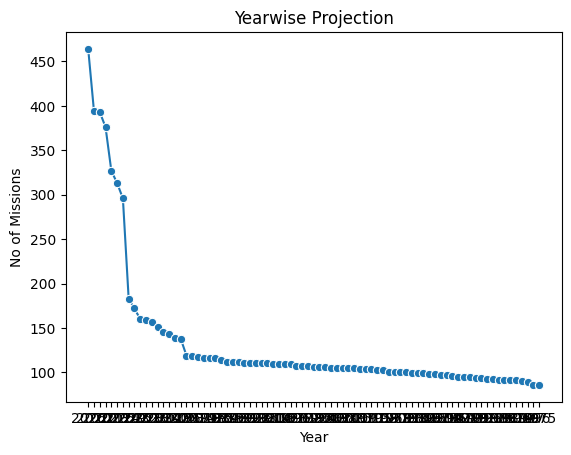

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=Year, y=Year_val, marker="o")

plt.title("Yearwise Projection")
plt.xlabel("Year")
plt.ylabel("No of Missions")
plt.show()